# 🤖 2. Selective Preprocessing - Classification model with NO Dropouts
**Deep learning model for blue fundus eye pictures classification**

The purpose of this notebook is to evaluate the binary myopia classification model across different selective preprocessing scenarios.

The classification target is derived from the spherical equivalent value:

- `class_label = 1`: myopic eye, defined as `target_SE <= -0.50 D`
- `class_label = 0`: non-myopic eye, defined as `target_SE > -0.50 D`

The same lightweight CNN architecture is trained on four preprocessing scenarios:

A. Normalization only
- With RGB conversion and normalization to [0–1].
- No geometry: no circle detection, nor padding/resizing (only dataloader resizer for 224×224 pixels).
- No CLAHE.
- No Augmentations.

B. Geometry + Normalization
- With RGB conversion and normalization to [0–1].
- With geometry: fundus circle detection + circular crop + padding to square + resizing to 224×224.
- No CLAHE.
- No Augmentations.

C. Geometry + Normalization + Illumination (no Augmentantions)
- With RGB conversion and normalization to [0–1].
- With geometry: fundus circle detection + circular crop + padding to square + resizing to 224×224.
- With CLAHE (luminance or blue can be chosen).
- No Augmentations.

D. Geometry + Normalization + Augmentations (no illumination)
- With RGB conversion and normalization to [0–1].
- With geometry: fundus circle detection + circular crop + padding to square + resizing to 224×224.
- No CLAHE.
- With geometric Augmentations: flip, light rotation and zoom applied at dataloader.

## ⚙️ 1. Setting up



In [1]:
from pathlib import Path #useful since it makes path use easier (can append paths and more)
import os, random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import importlib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# from sklearn.model_selection import train_test_split - not necessary now, we will import splits
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report
)

# Load configurable project paths ============================================================

# Project root detection
PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / "config.yaml").exists():
    if PROJECT_ROOT == PROJECT_ROOT.parent:
        raise FileNotFoundError("config.yaml was not found. Make sure it is located in the project root.")
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

importlib.invalidate_caches()

from src.paths import (
    load_config,
    get_paths,
    validate_main_structure,
    print_paths
)

cfg = load_config(PROJECT_ROOT / "config.yaml")

paths = get_paths(cfg)
validate_main_structure(paths)

# General settings ===========================================================

SEED = int(cfg["settings"]["seed"])
IMG_SIZE = tuple(cfg["settings"]["image_size"]) #from config.yaml - must match the preprocessed size
BATCH = int(cfg["settings"]["batch_size"]) #from config.yaml - number of images preprocessed in each training step
AUTOTUNE = tf.data.AUTOTUNE #allows for paralelism automation

tf.keras.utils.set_random_seed(SEED)  #locks Python, NumPy and TF seed
tf.config.experimental.enable_op_determinism() #makes same deterministic ops

# Paths ===========================================================

IMAGES_DIR = paths["images"]
TABLES_DIR = paths["tables"]
SPLITS_DIR = paths["splits"]
MODELS_DIR = paths["models"]

for folder in [IMAGES_DIR, TABLES_DIR, SPLITS_DIR, MODELS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Images dir:", IMAGES_DIR)
print("Tables dir:", TABLES_DIR)
print("Splits dir:", SPLITS_DIR)
print("Models dir:", MODELS_DIR)
print("IMG_SIZE:", IMG_SIZE)
print("BATCH:", BATCH)
print("SEED:", SEED)

Project root: C:\Users\paula\0B_TFGBiomed_Exe
Images dir: C:\Users\paula\0B_TFGBiomed_Exe\Images
Tables dir: C:\Users\paula\0B_TFGBiomed_Exe\Tables
Splits dir: C:\Users\paula\0B_TFGBiomed_Exe\Splits
Models dir: C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave
IMG_SIZE: (224, 224)
BATCH: 32
SEED: 42


In [2]:
# Selective preprocessing output folders ===========================================================

SPLIT_ROOT = SPLITS_DIR / "Classification" / "SelectivePreproc"
MODELS_DIR_SELECTIVE = MODELS_DIR / "WithoutDropout" / "SelectivePreproc" / "Classification"

SPLIT_ROOT.mkdir(parents=True, exist_ok=True)
MODELS_DIR_SELECTIVE.mkdir(parents=True, exist_ok=True)

print("Split root:", SPLIT_ROOT)
print("Models selective output:", MODELS_DIR_SELECTIVE)

Split root: C:\Users\paula\0B_TFGBiomed_Exe\Splits\Classification\SelectivePreproc
Models selective output: C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\WithoutDropout\SelectivePreproc\Classification


In [3]:
# Paths to selectively preprocessed sets of images
SCENARIO_TABLES = {
    "A_Raw_minimal": TABLES_DIR / "MatchTables" / "TablaMatch_SCENARIO.A.xlsx",         # Raw with minimal preproc
    "B_GeoNorm": TABLES_DIR / "MatchTables" / "TablaMatch_SCENARIO.B.xlsx",             # geometry + normalization
    "C_GeoNorm_Illum_NoAug": TABLES_DIR / "MatchTables" / "TablaMatch_SCENARIO.C.xlsx", # geometry + normalization + illumination 
    "D_GeoNorm_Aug_NoIllum": TABLES_DIR / "MatchTables" / "TablaMatch_SCENARIO.B.xlsx" # geometry + normalization + augmentations - there is no such path, will be using B for D
}

EXPERIMENTS = [ # (name, data_root, augment_in_loader, normalization)
    {
        "name": "A_Raw_minimal",
        "table": SCENARIO_TABLES["A_Raw_minimal"],
        "do_aug": False,
        "normalization": "0-1"
    },
    {
        "name": "B_GeoNorm",
        "table": SCENARIO_TABLES["B_GeoNorm"],
        "do_aug": False,
        "normalization": "0-1"
    },
    {
        "name": "C_GeoNorm_Illum_NoAug",
        "table": SCENARIO_TABLES["C_GeoNorm_Illum_NoAug"],
        "do_aug": False,
        "normalization": "0-1"
    },
    {
        "name": "D_GeoNorm_Aug_NoIllum",
        "table": SCENARIO_TABLES["D_GeoNorm_Aug_NoIllum"], #makes use of geom+norm to make augmentations without illumination
        "do_aug": True,
        "normalization": "0-1"
    }
]

for name, path in SCENARIO_TABLES.items():
    print(name, "exists:", path.exists(), "|", path)
    assert path.exists(), f"Missing scenario table: {path}"

A_Raw_minimal exists: True | C:\Users\paula\0B_TFGBiomed_Exe\Tables\MatchTables\TablaMatch_SCENARIO.A.xlsx
B_GeoNorm exists: True | C:\Users\paula\0B_TFGBiomed_Exe\Tables\MatchTables\TablaMatch_SCENARIO.B.xlsx
C_GeoNorm_Illum_NoAug exists: True | C:\Users\paula\0B_TFGBiomed_Exe\Tables\MatchTables\TablaMatch_SCENARIO.C.xlsx
D_GeoNorm_Aug_NoIllum exists: True | C:\Users\paula\0B_TFGBiomed_Exe\Tables\MatchTables\TablaMatch_SCENARIO.B.xlsx


## 🛠️  2. Helpers preparation

To keep the codebase clean and efficient, several helper functions were implemented.  
These functions encapsulate small, reusable tasks that will be required multiple times throughout the preprocessing pipeline.

####  2.1 Reading the tables

In [4]:
base_df = pd.read_excel(SCENARIO_TABLES["A_Raw_minimal"])

# Keep only rows with valid paths and classification labels
base_df = base_df[base_df["image_path"].notna()].copy()
base_df = base_df[base_df["filename"].notna()].copy()
base_df = base_df[base_df["class_label"].notna()].copy()

base_df["filename"] = base_df["filename"].astype(str)
base_df["patient_id"] = base_df["patient_id"].astype(str).str.upper().str.strip()
base_df["class_label"] = pd.to_numeric(base_df["class_label"], errors="coerce").astype("Int64")

base_df = base_df.dropna(
    subset=["image_path", "filename", "patient_id", "class_label"]
).copy()

base_df["class_label"] = base_df["class_label"].astype("int32")

print("Total valid images for classification:", len(base_df))

print("\nClassification label balance:")
print(base_df["class_label"].value_counts())

base_df.head()

Total valid images for classification: 2126

Classification label balance:
class_label
0    1645
1     481
Name: count, dtype: int64


,image_path,filename,patient_id,image_date_raw,image_date,modality,eye,nhc,FechaNacimiento,Edad,...,match_type,target_SE,class_label,original_image_path,preprocessing,image_size,detect_fundus,pad_and_resize,clahe_applied,clahe_mode
0,C:\Users\paula\0B_TFGBiomed\Images\02_Selectiv...,A6138_17092024_165654_Color_R_001.jpg,A6138,17092024,2024-09-17,Color,R,A6138,2020-06-03,6,...,id+date,0.000,0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A_Raw_minimal,224,False,False,False,none
1,C:\Users\paula\0B_TFGBiomed\Images\02_Selectiv...,A6138_17092024_165721_Color_L_001.jpg,A6138,17092024,2024-09-17,Color,L,A6138,2020-06-03,6,...,id+date,0.000,0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A_Raw_minimal,224,False,False,False,none
2,C:\Users\paula\0B_TFGBiomed\Images\02_Selectiv...,A6140_11122023_191157_IR_R_001.jpg,A6140,11122023,2023-12-11,IR,R,A6140,1975-10-06,51,...,id+date,-2.250,1,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A_Raw_minimal,224,False,False,False,none
3,C:\Users\paula\0B_TFGBiomed\Images\02_Selectiv...,A6140_11122023_191221_IR_L_001.jpg,A6140,11122023,2023-12-11,IR,L,A6140,1975-10-06,51,...,id+date,-0.625,1,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A_Raw_minimal,224,False,False,False,none
4,C:\Users\paula\0B_TFGBiomed\Images\02_Selectiv...,A6142_12042023_153339_Color_R_001.jpg,A6142,12042023,2023-04-12,Color,R,A6142,2000-07-08,26,...,id+date,0.000,0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A_Raw_minimal,224,False,False,False,none


The classification dataset used here is the same one used in the previous selective classification notebook: **2,126 valid images**, with **1,645 normal images** and **481 myopic images**.

This confirms a strong class imbalance: around **77% normal** and **23% myopic** images. Therefore, accuracy must be interpreted carefully. A model predicting every image as normal would already obtain approximately **0.78 accuracy**, so AUC, AP and the confusion matrices are more informative for judging whether the model is truly learning to separate both classes.

Compared with the selective classification notebook **with Dropout**, the dataset and split logic remain the same. Therefore, any differences observed in the results can mainly be attributed to removing Dropout, not to changes in the input data.


#### ✂️  2.2 Splitting the dataset
Stratified (avoids bias since myope class is slightly bigger than the normal one) 80/10/10 split by chosen root dataset.

A single stratified 80/10/10 split is created from the clinical match table.

The same split is reused across all preprocessing scenarios, ensuring that the comparison between A, B, C and D is fair.

In [5]:
# Stratified 80/10/10 split based on class_label loaded from 00_CreatePatientLevelSplits_Classf_Regrss.ipynb

def load_existing_scenario_split(scenario_name: str) -> dict:
    scenario_split_dir = SPLIT_ROOT / scenario_name

    train_csv = scenario_split_dir / "train.csv"
    val_csv   = scenario_split_dir / "val.csv"
    test_csv  = scenario_split_dir / "test.csv"

    for csv_path in [train_csv, val_csv, test_csv]:
        if not csv_path.exists():
            raise FileNotFoundError(
                f"Missing split file: {csv_path}. "
                "Run 00_CreatePatientLevelSplits_Classf_Regrss.ipynb first."
            )

    return {
        "train": train_csv,
        "val": val_csv,
        "test": test_csv,
    }


def check_no_overlap(train_df, val_df, test_df, column: str, name: str) -> None:
    train_values = set(train_df[column].astype(str))
    val_values   = set(val_df[column].astype(str))
    test_values  = set(test_df[column].astype(str))

    assert len(train_values & val_values) == 0, f"{name}: overlap between train and val"
    assert len(train_values & test_values) == 0, f"{name}: overlap between train and test"
    assert len(val_values & test_values) == 0, f"{name}: overlap between val and test"

    print(f"OK: no {name} overlap across train/val/test.")


SCENARIO_SPLITS = {}

for exp in EXPERIMENTS:
    name = exp["name"]
    SCENARIO_SPLITS[name] = load_existing_scenario_split(name)

    train_df = pd.read_csv(SCENARIO_SPLITS[name]["train"])
    val_df   = pd.read_csv(SCENARIO_SPLITS[name]["val"])
    test_df  = pd.read_csv(SCENARIO_SPLITS[name]["test"])

    print(f"\n===== {name} =====")
    print("Train:", len(train_df))
    print("Val:  ", len(val_df))
    print("Test: ", len(test_df))

    check_no_overlap(train_df, val_df, test_df, "patient_id", f"{name} patient")
    check_no_overlap(train_df, val_df, test_df, "image_path", f"{name} image")

    print("\nTrain class balance:")
    print(train_df["class_label"].value_counts())

    print("\nVal class balance:")
    print(val_df["class_label"].value_counts())

    print("\nTest class balance:")
    print(test_df["class_label"].value_counts())


===== A_Raw_minimal =====
Train: 1701
Val:   211
Test:  214
OK: no A_Raw_minimal patient overlap across train/val/test.
OK: no A_Raw_minimal image overlap across train/val/test.

Train class balance:
class_label
0    1313
1     388
Name: count, dtype: int64

Val class balance:
class_label
0    165
1     46
Name: count, dtype: int64

Test class balance:
class_label
0    167
1     47
Name: count, dtype: int64

===== B_GeoNorm =====
Train: 1701
Val:   211
Test:  214
OK: no B_GeoNorm patient overlap across train/val/test.
OK: no B_GeoNorm image overlap across train/val/test.

Train class balance:
class_label
0    1313
1     388
Name: count, dtype: int64

Val class balance:
class_label
0    165
1     46
Name: count, dtype: int64

Test class balance:
class_label
0    167
1     47
Name: count, dtype: int64

===== C_GeoNorm_Illum_NoAug =====
Train: 1701
Val:   211
Test:  214
OK: no C_GeoNorm_Illum_NoAug patient overlap across train/val/test.
OK: no C_GeoNorm_Illum_NoAug image overlap across t

The same 80/10/10 patient-level split is reused across all four preprocessing scenarios. The outputs confirm that there is **no patient overlap** and **no image overlap** between train, validation and test sets.

The class balance is also preserved across train, validation and test sets. The test set contains **167 normal images** and **47 myopic images**, again reinforcing that class imbalance must be considered when interpreting accuracy.


#### 🧮  2.3 Decoder and normalizer
Now we move onto building efficient TensorFlow datasets (tf.data pipeline) from image paths and labels, applying decoding, resizing, batching, and lightweight data augmentations for training. In other words, we are receiving a disk path and giving a tensor back.

Note: a tensor is the basic structure in TensorFlow (in deep learning frameworks). A picture would be a 3D tensor (hxwxchannels) and a batch of pictures would be a 4D tensor (hxwxcxbatch)

In [6]:
IMAGENET_MEAN = tf.constant([0.485, 0.456, 0.406], tf.float32) #mean pixels intensity on red, green, blue channels
IMAGENET_STD = tf.constant([0.229, 0.224, 0.225], tf.float32) #standard deviations on channels

def normalize_tensor(img_float01, mode="0-1"): # Applies the selected normalization strategy
    if mode == "0-1":
        return img_float01
    if mode == "imagenet":
        return (img_float01 - IMAGENET_MEAN) / IMAGENET_STD
    if mode == "zscore":
        mean = tf.reduce_mean(img_float01, axis=[0, 1], keepdims=True)
        std = tf.math.reduce_std(img_float01, axis=[0, 1], keepdims=True) + 1e-6
        return (img_float01 - mean) / std

    return img_float01

def decode_img(path, label, normalization="0-1"): # Reads, decodes, resizes and normalizes one image
    img = tf.io.read_file(path) #reades pic as bytes
    img = tf.image.decode_jpeg(img, channels=3) #decodes jpg into rgb tensor
    img = tf.image.convert_image_dtype(img, tf.float32) #converts to float [0,1]
    img = tf.image.resize(img, IMG_SIZE, method="bilinear") #rescales to 224x224
    img = normalize_tensor(img, mode=normalization)

    return img, tf.cast(label, tf.float32)  #gives pic+label back so dataloader knows the class it belongs to 

#### 🎭  2.4 Dataloader with(out) Lightweight augmentations
Creating the TensorFlow dataset (dataloader) with simple geometric transformations (or not) to improve generalization and reduce overfitting.

Shuffles and augmentations will only be applied if training=True

The model uses:
- three convolutional blocks,
- max pooling after the first two convolutions,
- global average pooling,
- dropout regularization,
- and a sigmoid output neuron for binary myopia classification

In [7]:
#Declare the type of augmentations to be carried out (if wanted)
augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"), #hozt flip (imitates eye flip)
    tf.keras.layers.RandomRotation(0.02), #slight rotation
    tf.keras.layers.RandomZoom(0.05), #slight random zoom
])

def make_classification_ds(csv_path, training=False, normalization="0-1", do_aug=False): # Creates a TensorFlow dataset for binary myopia classification
    split_df = pd.read_csv(csv_path) #cvs path is pic+label
    paths = split_df["image_path"].astype(str).values
    labels = split_df["class_label"].astype("float32").values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map( #applies decode_img on each image
        lambda p, y: decode_img(p, y, normalization=normalization),
        num_parallel_calls=AUTOTUNE 
    )

    if training: #if training, it shuffles (so it learns with random order) and applies augmentations 
        ds = ds.shuffle(8192, seed=SEED, reshuffle_each_iteration=True)

        if do_aug:
            ds = ds.map(
                lambda x, y: (augment(x, training=True), y),
                num_parallel_calls=AUTOTUNE #(aumentos)
            )

    ds = ds.batch(BATCH).prefetch(AUTOTUNE)  #prefetching makes pipeline faster; batch size declared up top

    return ds

#### 🟢  2.5 The classification model - small_cnn_classf

Definition of the small_cnn architecture used as a first baseline classifier. This was model small_cnn_classf on the Models_1FullPreproc.ipynb notebook.

In [8]:
def build_small_cnn_classf(input_shape=(224,224,3)):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs) #progressively extracts characteristics
    x = layers.MaxPool2D()(x) #reduces resolution and makes more compact/robust representation
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x) #zero-padding on borders so input is same size as output (in case kernel and input are different sizes?)
    x = layers.MaxPool2D()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling2D()(x) #compacts activation maps into mean value (lees params and less overfitting than Flatten)
    #x = layers.Dropout(0.3)(x) #randomly switches off 30% of neurons while training - NOT on this notebook
    outputs = layers.Dense(1, activation="sigmoid")(x) #binary exit (1 is the probability of myopia)
    return keras.Model(inputs, outputs)

def compile_model_classf():
    model = build_small_cnn_classf()
    model.compile(optimizer=keras.optimizers.Adam(1e-3), #Adam optimizer with lr=1e-3
                  loss="binary_crossentropy", #adecuate for binary classification with sigmoid
                  metrics=[keras.metrics.AUC(name="auc"), "accuracy"]) #AUC and accuracy metrics
    return model

In [9]:
example_model = compile_model_classf()
example_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 93,377 (364.75 KB)

 Trainable params: 93,377 (364.75 KB)

 Non-trainable params: 0 (0.00 B)

#### ⏱️  2.6 Callbacks and weights
Training monitors (earlystopping and learning-rate) scheduling for stability and later use.

Class weights are correction factors used during training to handle class' number differences: errors when choosing the minority class are penalized more strongly, while errors on the majority class are penalized less. This ensures the model pays equal attention to both classes despite unequal sample counts.

In [10]:
def make_callbacks():
    return [ 
        keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=5, restore_best_weights=True), #if AUC is not better after 5 epochs, goes back to previous weights
        keras.callbacks.ReduceLROnPlateau( monitor="val_auc", mode="max", factor=0.3, patience=2),#if AUC stays the same value after 2 epochs, LR gets reduced multiplying it by 0.3
    ]

def compute_weights(csv_train_path):
    train_df = pd.read_csv(csv_train_path) #Load train split
    
    classes = np.array([0,1])
    weights = compute_class_weight('balanced', classes=classes, y=train_df["class_label"].astype(int).values) #calcultes inverse weights to teh frecuency of each class
    return {0: float(weights[0]), 1: float(weights[1])} #dictionary understood by keras

#### 📦  2.7 Training and evalutation wrappers
Utility functions to make predictions on the dataset and evaluate results by stablished metrics.

In [11]:
#This function gives back true labels and predicted labels so as to calculate metrics later on
def collect_preds(model, ds): #dataset as ds
    y_true, y_score = [], [] #true labels 1 or 0; probabilities of model 0-1
    for xb, yb in ds:
        p = model.predict(xb, verbose=0).ravel()
        y_true.extend(yb.numpy().tolist())
        y_score.extend(p.tolist())
    y_true = np.array(y_true).astype(int)
    y_score = np.array(y_score).astype(float)
    return y_true, y_score

#Gives back a dictionary with: model name, AUC, AP, accuracy @50% threshold, confusion matrix and classification report
def evaluate_on_test(name, model, test_ds, threshold=0.5, show_plots=True):
    y_true, y_score = collect_preds(model, test_ds)
    y_pred = (y_score >= threshold).astype(int)

    #Metric 1: ROC / PR
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    prec, rec, _ = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)

    #Metric 2: Confusion matrix & report
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=["Normal","Myopia"], digits=4)

    if show_plots:
        # ROC
        plt.figure(figsize=(5,4))
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")
        plt.plot([0,1],[0,1],'--',alpha=0.5)
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC curve – {name}")
        plt.grid(True)
        plt.legend()
        plt.show()

        # PR
        plt.figure(figsize=(5,4))
        plt.plot(rec, prec, label=f"{name} (AP={ap:.3f})")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("Precision–Recall curve – {name}")
        plt.grid(True)
        plt.legend()
        plt.show()

        # Confusion matrix
        plt.figure(figsize=(4,3.6))
        plt.imshow(cm, cmap="Blues")
        plt.title(f"Confusion Matrix – {name}")
        plt.xticks([0,1], ["Normal","Myopia"])
        plt.yticks([0,1], ["Normal","Myopia"])
        for i in range(2):
            for j in range(2):
                plt.text(j, i, cm[i,j], ha="center", va="center")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.colorbar(fraction=0.046, pad=0.04)
        plt.tight_layout()
        plt.show()

    return {
        "name": name,
        "AUC": float(roc_auc),
        "AP": float(ap),
        "accuracy@0.5": float((y_pred == y_true).mean()),
        "confusion_matrix": cm,
        "report": report
    }

#### 🧪  2.8 Running the experiment
Full pipeline of model.

Each preprocessing scenario is trained independently using the same model architecture, same train/validation/test split, and same training configuration.

The only differences across experiments are:
- the image preprocessing level,
- and whether training-time augmentation is applied.

In [12]:
def run_experiment(exp, epochs=10):
    name = exp["name"]
    normalization = exp["normalization"]
    do_aug = exp["do_aug"]
    print(f"\n===== Running {name} =====")

    # 1) Splits (by root)
    #csv_name = ALIAS_SPLITS.get(name, name) #patch for D
    train_csv = SCENARIO_SPLITS[name]["train"]
    val_csv = SCENARIO_SPLITS[name]["val"]
    test_csv = SCENARIO_SPLITS[name]["test"]

    # In case B's CSVs didn't exist yet either - more patch for D
    #if not (os.path.exists(train_csv) and os.path.exists(val_csv) and os.path.exists(test_csv)):
    #    make_splits_for_root(data_root, out_prefix=csv_name, seed=SEED)
    
    # 2) Datasets
    train_ds = make_classification_ds(train_csv, training=True,  normalization=normalization, do_aug=do_aug)
    val_ds   = make_classification_ds(val_csv,   training=False, normalization=normalization, do_aug=False)
    test_ds  = make_classification_ds(test_csv,  training=False, normalization=normalization, do_aug=False)

    # 3) Model
    model = compile_model_classf()
    
    # 4) Class weights + callbacks
    class_weight = compute_weights(train_csv)
    print("Class weights:", class_weight)
    cb = make_callbacks()

    # 5) Train
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=cb, class_weight=class_weight)

    # 6) Evaluate
    test_metrics = evaluate_on_test(name, model, test_ds, show_plots=True)
    print(test_metrics["report"])
    
    return model, history, test_metrics, (train_ds, val_ds, test_ds)


## 🚀 3. The launching of the model

Now, we'll launch the binary classification (small_cnn_classf), that is CPU friendly and compiles it with Adam and binary cross-entropy, adds AUC/accuracy metrics, uses early stopping and learning-rate reduction on plateau, computes class weights from the train split, and trains the model with the tf.data pipelines.

We'll be applying it on the 4 baselines:

🇦 2.1 Small CNN with raw images - Mere normalization.

🇧 2.2 Small CNN with no Illumination and no Augmentations - This time only geometry and normalization preprocessing are applied.

🇨 2.3 Small CNN with Illumination (no augmentations) - This time only geometry, normalization and illumination preprocessing are applied.

🇩 2.4 Small CNN with Augmentations (no illumination) - This time only geometry, normalization and augmentations are applied.


===== Running A_Raw_minimal =====
Class weights: {0: 0.6477532368621478, 1: 2.1920103092783507}
Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.4859 - auc: 0.4484 - loss: 0.6972 - val_accuracy: 0.7820 - val_auc: 0.5192 - val_loss: 0.6880 - learning_rate: 0.0010
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.7632 - auc: 0.5049 - loss: 0.7017 - val_accuracy: 0.7820 - val_auc: 0.5470 - val_loss: 0.6820 - learning_rate: 0.0010
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.6098 - auc: 0.5448 - loss: 0.6965 - val_accuracy: 0.7820 - val_auc: 0.5818 - val_loss: 0.6681 - learning_rate: 0.0010
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step - accuracy: 0.4654 - auc: 0.5658 - loss: 0.6870 - val_accuracy: 0.4929 - val_auc: 0.6163 - val_loss: 0.6922 - learning_rate: 0.0010
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.6620 - auc: 0.5751 - loss: 0.6969 - val_accuracy: 0.7204 - val_auc: 0.5735 - val_loss: 0.6727 - learning_r

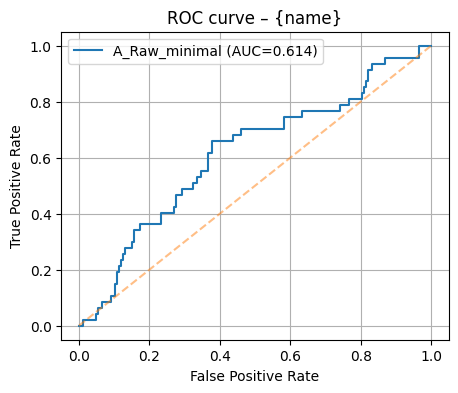

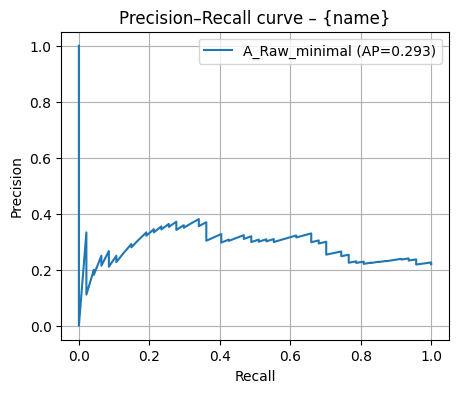

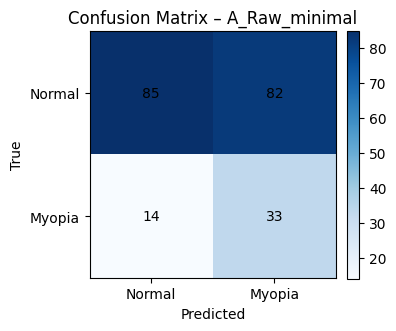

              precision    recall  f1-score   support

      Normal     0.8586    0.5090    0.6391       167
      Myopia     0.2870    0.7021    0.4074        47

    accuracy                         0.5514       214
   macro avg     0.5728    0.6056    0.5233       214
weighted avg     0.7330    0.5514    0.5882       214


===== Running B_GeoNorm =====
Class weights: {0: 0.6477532368621478, 1: 2.1920103092783507}
Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.5011 - auc: 0.4323 - loss: 0.6950 - val_accuracy: 0.7820 - val_auc: 0.5123 - val_loss: 0.6894 - learning_rate: 0.0010
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.7546 - auc: 0.5527 - loss: 0.7016 - val_accuracy: 0.7346 - val_auc: 0.5821 - val_loss: 0.6867 - learning_rate: 0.0010
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.5175 - auc: 0.5355 - loss: 0.6964 - val_accuracy: 0.7441 - val_auc: 0.5570 - val_loss: 0.6769 - learning_rate: 0.0010
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━

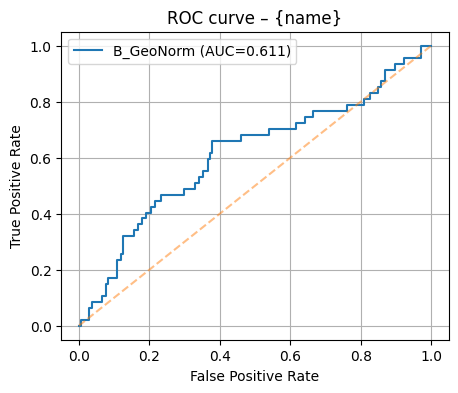

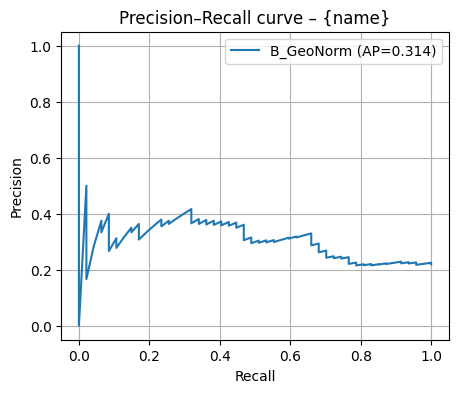

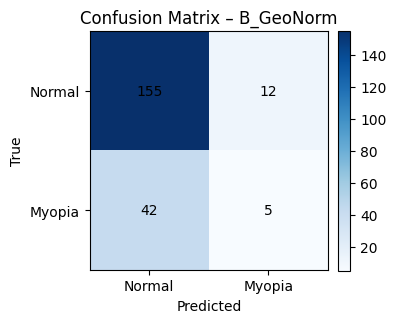

              precision    recall  f1-score   support

      Normal     0.7868    0.9281    0.8516       167
      Myopia     0.2941    0.1064    0.1562        47

    accuracy                         0.7477       214
   macro avg     0.5405    0.5173    0.5039       214
weighted avg     0.6786    0.7477    0.6989       214


===== Running C_GeoNorm_Illum_NoAug =====
Class weights: {0: 0.6477532368621478, 1: 2.1920103092783507}
Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.4805 - auc: 0.4423 - loss: 0.6966 - val_accuracy: 0.7820 - val_auc: 0.5524 - val_loss: 0.6895 - learning_rate: 0.0010
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 54s 969ms/step - accuracy: 0.7057 - auc: 0.5694 - loss: 0.7011 - val_accuracy: 0.4597 - val_auc: 0.5701 - val_loss: 0.6918 - learning_rate: 0.0010
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 57s 995ms/step - accuracy: 0.4996 - auc: 0.5582 - loss: 0.6952 - val_accuracy: 0.3460 - val_auc: 0.5634 - val_loss: 0.7071 - learning_rate: 0.0010
Epoch 4/10
54/54

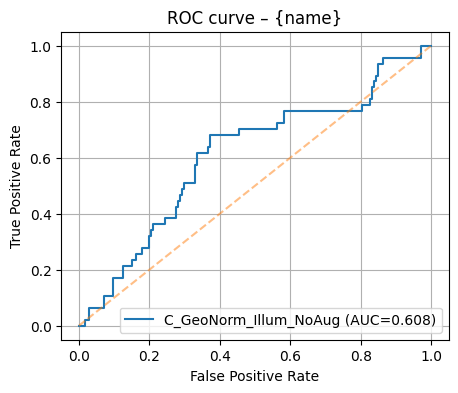

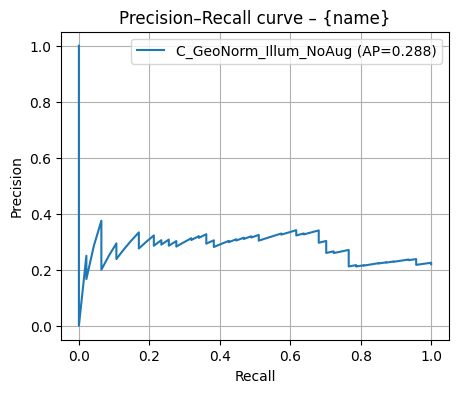

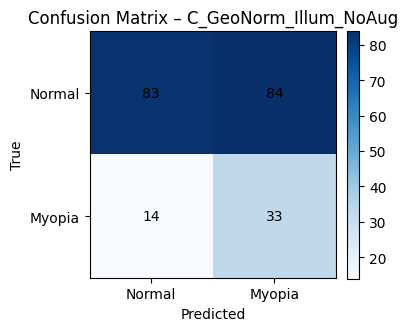

              precision    recall  f1-score   support

      Normal     0.8557    0.4970    0.6288       167
      Myopia     0.2821    0.7021    0.4024        47

    accuracy                         0.5421       214
   macro avg     0.5689    0.5996    0.5156       214
weighted avg     0.7297    0.5421    0.5791       214


===== Running D_GeoNorm_Aug_NoIllum =====
Class weights: {0: 0.6477532368621478, 1: 2.1920103092783507}
Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.5202 - auc: 0.4486 - loss: 0.6980 - val_accuracy: 0.7820 - val_auc: 0.5285 - val_loss: 0.6848 - learning_rate: 0.0010
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.7513 - auc: 0.5690 - loss: 0.7014 - val_accuracy: 0.5071 - val_auc: 0.5629 - val_loss: 0.6900 - learning_rate: 0.0010
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.4559 - auc: 0.5466 - loss: 0.6951 - val_accuracy: 0.3412 - val_auc: 0.5574 - val_loss: 0.7142 - learning_rate: 0.0010
Epoch 4/10
54/54 ━━━━━

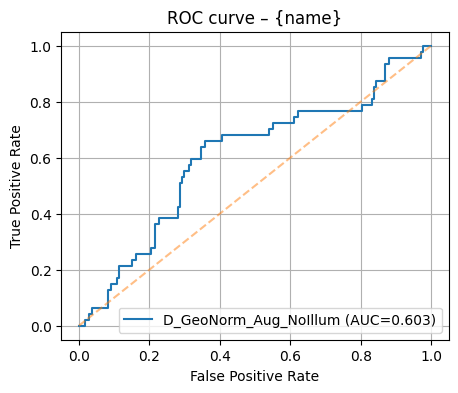

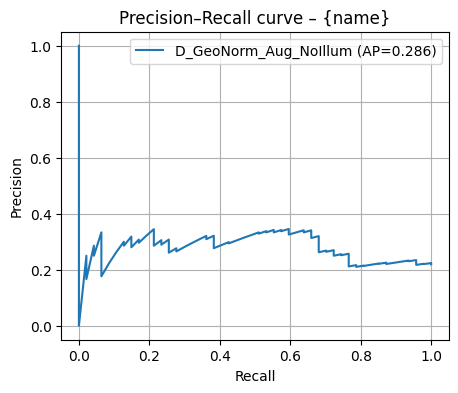

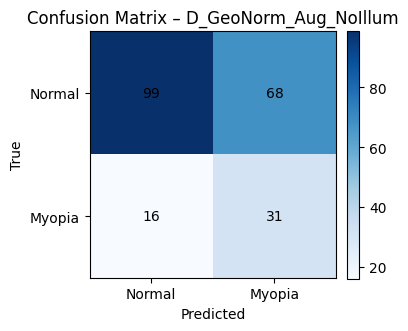

              precision    recall  f1-score   support

      Normal     0.8609    0.5928    0.7021       167
      Myopia     0.3131    0.6596    0.4247        47

    accuracy                         0.6075       214
   macro avg     0.5870    0.6262    0.5634       214
weighted avg     0.7406    0.6075    0.6412       214



,name,task,preprocessing_family,dropout,augmentation,normalization,best_val_auc,best_val_accuracy,test_auc,test_ap,test_accuracy@0.5,model_path
0,A_Raw_minimal,classification,SelectivePreproc,False,False,0-1,0.616271,0.781991,0.613836,0.292752,0.551402,C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\W...
1,B_GeoNorm,classification,SelectivePreproc,False,False,0-1,0.582148,0.781991,0.611161,0.313536,0.747664,C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\W...
2,C_GeoNorm_Illum_NoAug,classification,SelectivePreproc,False,False,0-1,0.570092,0.781991,0.607593,0.288444,0.542056,C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\W...
3,D_GeoNorm_Aug_NoIllum,classification,SelectivePreproc,False,True,0-1,0.562912,0.781991,0.602752,0.285907,0.607477,C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\W...


In [13]:
results = []
models  = {}
histories = {}
datasets = {}

for exp in EXPERIMENTS:
    mdl, hist, metrics, ds_tuple = run_experiment(exp, epochs=10)

    name = exp["name"]
    models[name] = mdl
    histories[name] = hist
    datasets[name] = ds_tuple

    model_path = MODELS_DIR_SELECTIVE / f"small_cnn_classification_without_dropout_{name}.keras"
    mdl.save(model_path)
    
    results.append({
        "name": name,
        "task": "classification",
        "preprocessing_family": "SelectivePreproc",
        "dropout": False,
        "augmentation": exp["do_aug"],
        "normalization": exp["normalization"],
        "best_val_auc": float(np.max(hist.history.get("val_auc", [np.nan]))),
        "best_val_accuracy": float(np.max(hist.history.get("val_accuracy", [np.nan]))),
        "test_auc": metrics["AUC"],
        "test_ap": metrics["AP"],
        "test_accuracy@0.5": metrics["accuracy@0.5"],
        "model_path": str(model_path)
    })

results_df = pd.DataFrame(results)
results_df

The results table shows a comparative of the same model (small_cnn_classf) run over the 4 different sets of preprocessed pictures:
- best_val_auc: best AUC value (capacity of model to distinguish classes) obtained accross the 10 epochs on the **validation set** (1 perfect, 0.5 random)
- best_val_acc: best accuracy value (% of right guesses) obtained accross the 10 epochs on the **validation set** (watch out for unbalanced classes in dataset)
- test_auc: AUC obtained on **test set**. This might be the most important metric
- test_ap: average precision obtained on **test set** (area under precision-recall curve). Very useful with unbalanced classes since it focuses on performance on myopia class
- test_acc@0.5: accuracy obtained on **test set** when 0.5 threshold is applied (≥ 0.5 means myopia); < 0.5 means normal)

All in all:
- AUC shows how well the model distinguishes amongst classes
- Accuracy shows % of right guesses when classifying
- AP shows how well the model handles the minority class (looking at precision vs recall)


Note 1: if overfitting is seen we may increase the dropout rate, add L2 on Conv2D or increase augmentations.

Note 2: handling the smaller class (AP) can be complicated since, if there is a large picture number difference amongst classes, the model might learn to state it is almost always right to predict that a picture belongs to the larger group when classifying.

The four selective preprocessing scenarios were trained using the same **small_cnn_classf without Dropout**. Overall, the results remain limited. Test AUC values are very close across all scenarios, ranging from approximately **0.603 to 0.614**, which means that none of the preprocessing levels provides strong class separation.

The best test AUC is obtained by **A_Raw_minimal** with **AUC = 0.614**, followed very closely by **B_GeoNorm** with **AUC = 0.611**, **C_GeoNorm_Illum_NoAug** with **AUC = 0.608** and **D_GeoNorm_Aug_NoIllum** with **AUC = 0.603**. Therefore, in terms of global discrimination, the simplest preprocessing scenario remains slightly ahead, but the difference is too small to claim a strong advantage.

The best Average Precision is obtained by **B_GeoNorm** with **AP = 0.314**. This differs from the previous selective classification notebook with Dropout, where **C_GeoNorm_Illum_NoAug** obtained the highest AP. This suggests that removing Dropout changes the ranking behaviour of the model, but not enough to make the classification task robust.

The highest accuracy at threshold 0.5 is also obtained by **B_GeoNorm**, with **accuracy = 0.748**. However, this value must be interpreted carefully: it is close to the majority-class baseline of around **0.78**, and the classification report shows that this scenario detects very few myopic cases. In other words, the high accuracy is mostly driven by predicting normal images correctly, not by balanced performance across both classes.

The confusion matrices show two different behaviours. Scenarios **A** and **C** recover many myopic cases, with myopia recall around **0.70**, but at the cost of many false positives and low myopia precision. Scenario **B** behaves almost in the opposite way: it predicts most images as normal, leading to high normal recall but very poor myopia recall (**0.106**). Scenario **D** is intermediate, with myopia recall around **0.66** and slightly better myopia precision than A and C, although still low.

Compared with the selective classification notebook **with Dropout**, removing Dropout does **not** clearly improve AUC. The AUC values remain almost unchanged: A decreases slightly from **0.622 to 0.614**, B increases slightly from **0.606 to 0.611**, C increases slightly from **0.604 to 0.608**, and D remains almost the same. Therefore, Dropout does not seem to be the main factor limiting the model.

-> The main visible change after removing Dropout is not better discrimination, but a change in threshold behaviour. Some scenarios now predict more normal images, which increases accuracy, but this does not necessarily mean that the model is clinically better.


## 📊 4. Results

#### 📈 4.1 Plot histories
Plotting training and validation curves (AUC, accuracy, or loss) for Keras models, making it easy to compare performance across epochs.

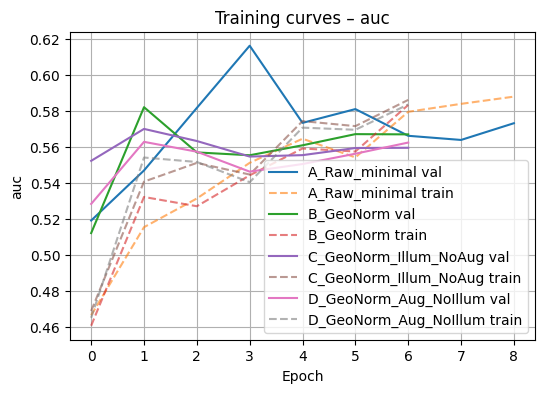

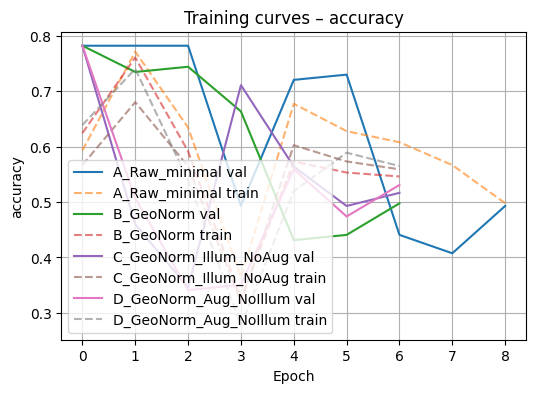

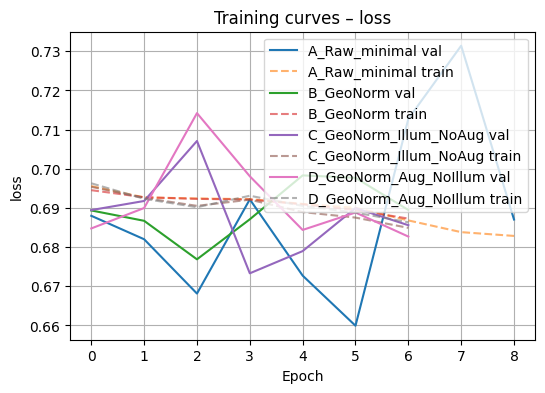

In [14]:
def plot_histories(histories_dict, metric="auc"):
    # histories_dict: dictionary of keras History objects
    # metric: "auc" | "accuracy" | "loss" | "mae" | "mse"

    plt.figure(figsize=(6, 4)) # prefer validation metric if available

    plotted_anything = False

    for name, history in histories_dict.items():
        hist = history.history

        if f"val_{metric}" in hist:
            plt.plot(hist[f"val_{metric}"], label=f"{name} val")
            plotted_anything = True

        if metric in hist:
            plt.plot(hist[metric], linestyle="--", alpha=0.6, label=f"{name} train")
            plotted_anything = True

    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.title(f"Training curves – {metric}")
    plt.grid(True)

    if plotted_anything:
        plt.legend()
    else:
        print(f"No history found for metric: {metric}")

    plt.show()

plot_histories(histories, metric="auc")
plot_histories(histories, metric="accuracy")
plot_histories(histories, metric="loss")

The training curves show unstable learning across scenarios. Validation AUC values remain low and close to each other, with no scenario showing a clear and sustained improvement over the others.

The best validation AUC is obtained by **A_Raw_minimal** with approximately **0.616**, but the remaining scenarios stay between **0.563 and 0.582**. These values are only slightly above random performance, confirming that the model is learning a weak signal at most.

The validation accuracy curves are not very informative because of class imbalance. In several epochs, validation accuracy approaches the majority-class baseline, which may simply indicate that the model is predicting more normal cases rather than improving real discrimination.

Compared with the previous selective model with Dropout, **the training process without Dropout does not become clearly better. It remains noisy and does not produce a strong validation AUC improvement.**


#### ⚖️ 4.2 Direct comparison A vs B vs C vs D on ROC & PR
This code evaluates multiple outcomes on the same test set, computes ROC and Precision–Recall curves (with AUC and AP), and overlays the curves to compare their performance directly.

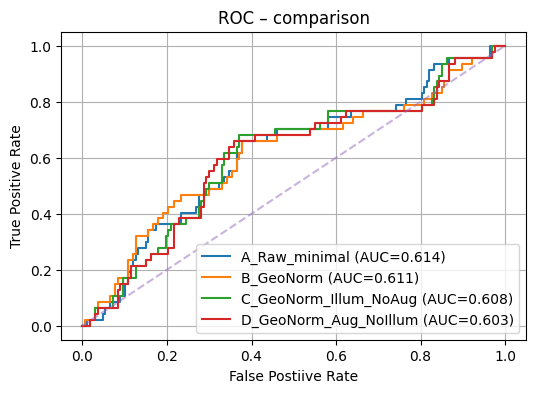

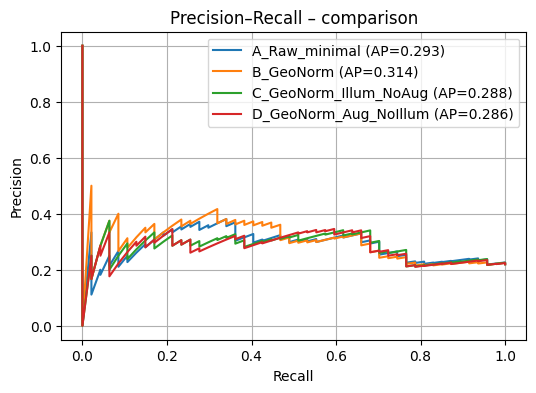

In [15]:
def compare_models_on_test(model_dict, scenario_splits, normalization="0-1"):
    
    curves = {}
    for name, mdl in model_dict.items():
        #csv_name = ALIAS_SPLITS.get(name, name)  #B for D patch
        test_csv = scenario_splits[name]["test"]  # created in run_experiment
        test_ds  = make_classification_ds(test_csv, training=False, normalization=normalization, do_aug=False)
        y_true, y_score = collect_preds(mdl, test_ds)
        fpr, tpr, _ = roc_curve(y_true, y_score)
        precision, recall, _ = precision_recall_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)
        ap = average_precision_score(y_true, y_score)
        curves[name] = {"fpr":fpr,"tpr":tpr,"auc":roc_auc,"precision":precision,"recall":recall,"ap":ap}

    # ROC overlay
    plt.figure(figsize=(6,4))
    for name, d in curves.items():
        plt.plot(d["fpr"], d["tpr"], label=f"{name} (AUC={d['auc']:.3f})")
    plt.plot([0,1],[0,1],'--',alpha=0.5)
    plt.xlabel("False Postiive Rate"); plt.ylabel("True Positive Rate")
    plt.title("ROC – comparison")
    plt.grid(True); plt.legend(); plt.show()

    # PR overlay
    plt.figure(figsize=(6,4))
    for name, d in curves.items():
        plt.plot(d["recall"], d["precision"], label=f"{name} (AP={d['ap']:.3f})")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title("Precision–Recall – comparison")
    plt.grid(True); plt.legend(); plt.show()

    return curves


classification_curves = compare_models_on_test(
    models,
    SCENARIO_SPLITS,
    normalization="0-1"
)

The ROC comparison confirms that all four preprocessing scenarios behave similarly. The curves remain relatively close to the diagonal reference line, and none of the scenarios reaches a strong AUC.

The Precision-Recall comparison is especially useful here because myopia is the minority class. The AP values remain low, between approximately **0.286 and 0.314**. This means that the model struggles to identify myopic images with enough precision across the recall range.

Scenario **B_GeoNorm** obtains the best AP and the highest threshold-based accuracy, but its confusion matrix reveals that this comes with very poor myopia recall. Therefore, B should not be interpreted as a clinically good model despite its better accuracy.

Scenario **A_Raw_minimal** remains the best by AUC, while **B_GeoNorm** becomes the best by AP. This disagreement between metrics reinforces that there is no clearly successful preprocessing strategy in this notebook.


Compared with the selective classification notebook **with Dropout**, the AUC values are very similar, while the threshold-based accuracies are generally higher in this no-Dropout notebook. However, this increase in accuracy is mostly caused by a shift in predicted labels, especially in scenario B, rather than by a strong improvement in class separation.

Compared with the **FullPreproc without Dropout** notebook, the selective scenarios perform slightly better in AUC: FullPreproc without Dropout obtained approximately **AUC = 0.591**, while the selective scenarios here obtain values around **0.603–0.614**. This suggests that selective preprocessing may be slightly preferable to the full pipeline when Dropout is removed, although the improvement remains modest.

Overall, the model still does not provide reliable binary myopia classification. It shows a weak signal, but the combination of class imbalance, low AP and unstable threshold behaviour prevents this notebook from being considered a strong classification configuration.


#### 📝 4.3 Conclusions

The dataset is strongly imbalanced, with approximately **77% normal images** and **23% myopic images**. Because of this, accuracy must be interpreted with caution. A model predicting all test images as normal would reach approximately **0.78 accuracy**, so AUC, AP and confusion matrices are more relevant than accuracy alone.

The best scenario according to **test AUC** is **A_Raw_minimal**, with **AUC = 0.614**. This is very close to the result obtained in the selective classification notebook with Dropout, where A also performed best by AUC with **0.622**. Therefore, removing Dropout does not improve the model's global class-separation ability.

The best scenario according to **Average Precision** is **B_GeoNorm**, with **AP = 0.314**. However, this scenario has very low myopia recall (**0.106**), meaning that it misses most myopic cases. Its high accuracy (**0.748**) is therefore misleading, because it is mainly explained by correctly predicting many normal images.

Scenarios **A** and **C** show higher myopia recall, around **0.70**, but they also produce many false positives, leading to low myopia precision. Scenario **D** is more balanced than A and C but still remains weak overall. None of the four scenarios achieves a clinically reliable balance between sensitivity and specificity.

Compared with the same selective classification experiment **with Dropout**, the no-Dropout version mainly changes the threshold behaviour, not the underlying discriminative capacity. AUC values remain around **0.60–0.61** in both notebooks. Therefore, Dropout does not appear to be the main reason for the limited classification performance.

Compared with the **FullPreproc without Dropout** notebook, the selective preprocessing scenarios perform slightly better by AUC. FullPreproc without Dropout obtained approximately **AUC = 0.591**, while the selective scenarios here reach up to **0.614**. This suggests that selective preprocessing may be slightly preferable to the full preprocessing pipeline in this no-Dropout setting, but the improvement is not large enough to make the model robust.

**Compared with the selective regression notebook, classification remains more promising than direct SE prediction.** The regression models showed R² values close to zero, indicating almost no useful continuous prediction of SE. In classification, the model at least shows a weak ability to rank myopic and normal images, although this ability is still limited.

-> Overall, this notebook shows that **removing Dropout does not substantially improve selective-preprocessing classification**. The model remains weak, with low AUC and low AP values, and the apparent accuracy improvements are mostly explained by threshold behaviour and class imbalance. These results support the idea that the main limitation is not Dropout itself, but the difficulty of extracting a robust myopia signal from the available clinical retinal images using this small CNN configuration.

All in all:

When Dropout was removed from the selective-preprocessing classification model, the test AUC values remained very similar to the equivalent model with Dropout, around 0.60–0.61. The apparent increase in accuracy in some scenarios was mainly caused by a shift towards predicting more normal cases, not by a clear improvement in class discrimination. A_Raw_minimal remained the best scenario by AUC, while B_GeoNorm achieved the highest AP and accuracy but missed most myopic cases. Therefore, removing Dropout changed the threshold behaviour of the model but did not meaningfully improve its ability to distinguish myopic from normal retinal images.

End :)